In [1]:
import pandas as pd

import numpy  as np

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
sales = pd.read_csv(r"D:\My Statistics\Pandas\Datasets\Maven Toys Data\sales.csv")

In [3]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Sale_ID     829262 non-null  int64 
 1   Date        829262 non-null  object
 2   Store_ID    829262 non-null  int64 
 3   Product_ID  829262 non-null  int64 
 4   Units       829262 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 31.6+ MB


In [4]:
products = pd.read_csv(r"D:\My Statistics\Pandas\Datasets\Maven Toys Data\products.csv")

In [5]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product_ID        35 non-null     int64 
 1   Product_Name      35 non-null     object
 2   Product_Category  35 non-null     object
 3   Product_Cost      35 non-null     object
 4   Product_Price     35 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.5+ KB


In [6]:
stores = pd.read_csv(r"D:\My Statistics\Pandas\Datasets\Maven Toys Data\stores.csv")

In [7]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Store_ID         50 non-null     int64 
 1   Store_Name       50 non-null     object
 2   Store_City       50 non-null     object
 3   Store_Location   50 non-null     object
 4   Store_Open_Date  50 non-null     object
dtypes: int64(1), object(4)
memory usage: 2.1+ KB


In [8]:
inventory = pd.read_csv(r"D:\My Statistics\Pandas\Datasets\Maven Toys Data\inventory.csv")

In [9]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Store_ID       1593 non-null   int64
 1   Product_ID     1593 non-null   int64
 2   Stock_On_Hand  1593 non-null   int64
dtypes: int64(3)
memory usage: 37.5 KB


In [10]:
sales_pd = pd.merge(sales , products , on = 'Product_ID')

In [11]:
sales_stroes_pd = pd.merge(sales_pd , stores , on = 'Store_ID')

In [12]:
df = sales_stroes_pd.copy()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Sale_ID           829262 non-null  int64 
 1   Date              829262 non-null  object
 2   Store_ID          829262 non-null  int64 
 3   Product_ID        829262 non-null  int64 
 4   Units             829262 non-null  int64 
 5   Product_Name      829262 non-null  object
 6   Product_Category  829262 non-null  object
 7   Product_Cost      829262 non-null  object
 8   Product_Price     829262 non-null  object
 9   Store_Name        829262 non-null  object
 10  Store_City        829262 non-null  object
 11  Store_Location    829262 non-null  object
 12  Store_Open_Date   829262 non-null  object
dtypes: int64(4), object(9)
memory usage: 82.2+ MB


In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In our Product Price , the data type is object. we need to chage the data type to numeric data type.

At first , all prrice have $ symbol. we need to drop the symbol.

In [15]:
df['Product_Price'] = df['Product_Price'].str.replace('$' , '')

In [16]:
df['Product_Cost'] = df['Product_Cost'].str.replace('$' , '')

In [17]:
df['Product_Cost'] = pd.to_numeric(df['Product_Cost'])

In [18]:
df['Product_Price'] = pd.to_numeric(df['Product_Price'])

At first , we need to find the trend of Sales.

In [19]:
df['month_name'] = df['Date'].dt.strftime('%b')

In [20]:
df.head()

,Sale_ID,Date,Store_ID,Product_ID,Units,Product_Name,Product_Category,Product_Cost,Product_Price,Store_Name,Store_City,Store_Location,Store_Open_Date,month_name
0,1,2022-01-01,24,4,1,Chutes & Ladders,Games,9.99,12.99,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Jan
1,2,2022-01-01,28,1,1,Action Figure,Toys,9.99,15.99,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Jan
2,3,2022-01-01,6,8,1,Deck Of Cards,Games,3.99,6.99,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Jan
3,4,2022-01-01,48,7,1,Dart Gun,Sports & Outdoors,11.99,15.99,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Jan
4,5,2022-01-01,44,18,1,Lego Bricks,Toys,34.99,39.99,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Jan


In [21]:
df['Profit'] = (df['Product_Price'] - df['Product_Cost']) * df['Units']

In [22]:
df['Sales'] = df['Product_Price'] * df['Units']

In [23]:
pd.unique(df.duplicated()) ## checking this dataset has dupicate values.

array([False])

We need to find Top Stores by Sales. 

In [24]:
df.head()

,Sale_ID,Date,Store_ID,Product_ID,Units,Product_Name,Product_Category,Product_Cost,Product_Price,Store_Name,Store_City,Store_Location,Store_Open_Date,month_name,Profit,Sales
0,1,2022-01-01,24,4,1,Chutes & Ladders,Games,9.99,12.99,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Jan,3.0,12.99
1,2,2022-01-01,28,1,1,Action Figure,Toys,9.99,15.99,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Jan,6.0,15.99
2,3,2022-01-01,6,8,1,Deck Of Cards,Games,3.99,6.99,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Jan,3.0,6.99
3,4,2022-01-01,48,7,1,Dart Gun,Sports & Outdoors,11.99,15.99,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Jan,4.0,15.99
4,5,2022-01-01,44,18,1,Lego Bricks,Toys,34.99,39.99,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Jan,5.0,39.99


In [25]:
stores_sales = df.groupby('Store_Name').agg(Sales = ('Sales' , 'sum') , 
                             Profit = ('Profit' , 'sum')).sort_values('Sales' , ascending= False)

Top 10 Stores by sales

In [26]:
top_10 = stores_sales.head(10)

top_10

,Sales,Profit
Store_Name,,
Maven Toys Ciudad de Mexico 2,554553.43,169856.0
Maven Toys Guadalajara 3,449354.91,121571.0
Maven Toys Ciudad de Mexico 1,433556.21,111296.0
Maven Toys Toluca 1,411157.32,104612.0
Maven Toys Monterrey 2,372998.82,106783.0
Maven Toys Guadalajara 4,348466.64,102178.0
Maven Toys Hermosillo 3,344846.64,98825.0
Maven Toys Xalapa 2,344307.04,88637.0
Maven Toys Ciudad de Mexico 3,337424.66,94021.0


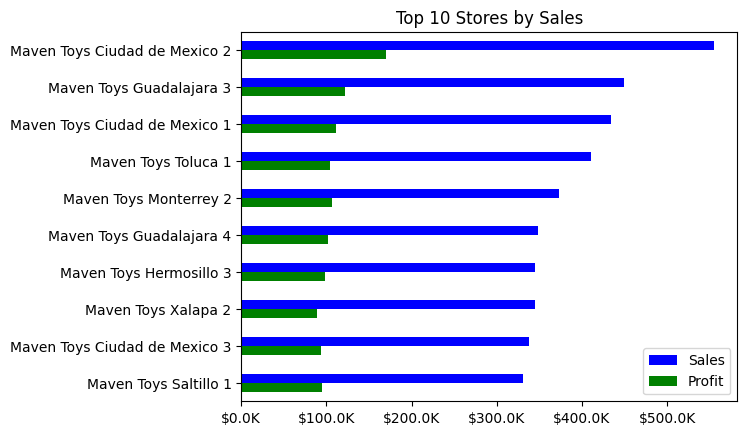

In [27]:
top_10.plot(kind= 'barh' , y = ['Sales' , 'Profit'] , color=['blue' , 'green'])
ax = plt.gca()
ax.set_title('Top 10 Stores by Sales')
ax.invert_yaxis()
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${x/1000}K'))

In [28]:
bottom_10 = stores_sales.tail(10)

bottom_10

,Sales,Profit
Store_Name,,
Maven Toys Pachuca 1,237676.15,63989.0
Maven Toys Hermosillo 1,235115.18,76788.0
Maven Toys Merida 1,232097.72,64399.0
Maven Toys Zacatecas 1,229983.04,59160.0
Maven Toys Tuxtla Gutierrez 1,229698.27,65787.0
Maven Toys Toluca 2,222364.36,58090.0
Maven Toys Durango 1,222318.78,62673.0
Maven Toys Cuernavaca 1,221587.26,56811.0
Maven Toys La Paz 1,210897.83,57407.0


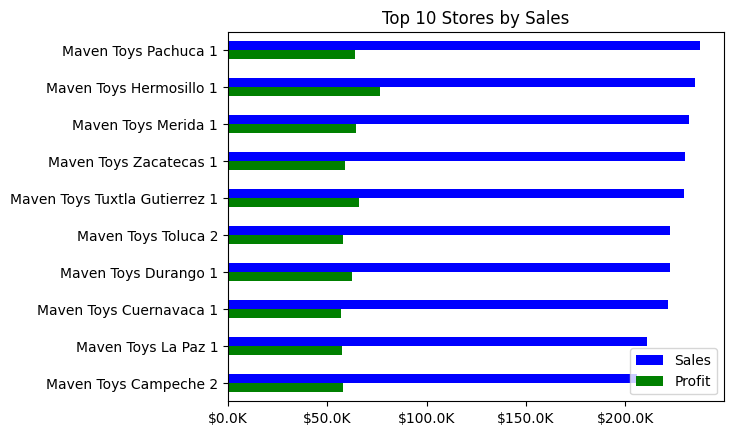

In [29]:
bottom_10.plot(kind= 'barh' , y = ['Sales' , 'Profit'] , color=['blue' , 'green'])
ax = plt.gca()
ax.set_title('Top 10 Stores by Sales')
ax.invert_yaxis()
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${x/1000}K'))

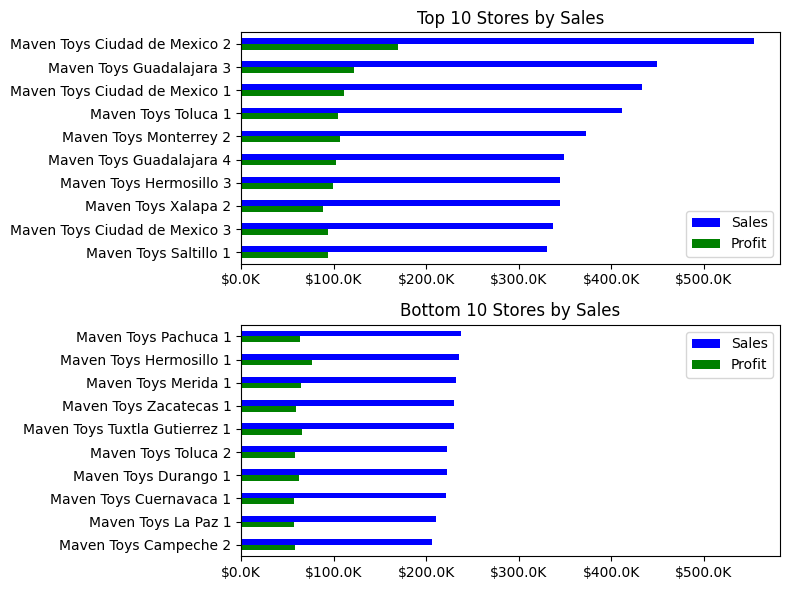

In [30]:
fig , ax = plt.subplots(2 , 1 ,figsize = (8 , 6))


top_10.plot(kind= 'barh' , y = ['Sales' , 'Profit'] , color=['blue' , 'green'] , ax = ax[0])
ax[0].set_title('Top 10 Stores by Sales')
ax[0].invert_yaxis()
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${x/1000}K'))

bottom_10.plot(kind= 'barh' , y = ['Sales' , 'Profit'] , color=['blue' , 'green'] , ax = ax[1])
ax[1].set_title('Bottom 10 Stores by Sales')
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${x/1000}K'))


fig.tight_layout()

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sale_ID           829262 non-null  int64         
 1   Date              829262 non-null  datetime64[ns]
 2   Store_ID          829262 non-null  int64         
 3   Product_ID        829262 non-null  int64         
 4   Units             829262 non-null  int64         
 5   Product_Name      829262 non-null  object        
 6   Product_Category  829262 non-null  object        
 7   Product_Cost      829262 non-null  float64       
 8   Product_Price     829262 non-null  float64       
 9   Store_Name        829262 non-null  object        
 10  Store_City        829262 non-null  object        
 11  Store_Location    829262 non-null  object        
 12  Store_Open_Date   829262 non-null  object        
 13  month_name        829262 non-null  object        
 14  Prof

In [32]:
df['Year'] = df['Date'].dt.year

In [33]:
sales_year= df.groupby(['Year' , 'Store_Name'])['Sales'].sum().reset_index().sort_values(['Year' , 'Sales'] , ascending=[True , False])

In [34]:
stores_rank_2022 = sales_year[sales_year['Year'] == 2022]

In [35]:
stores_rank_2023 = sales_year[sales_year['Year'] == 2023]

In [36]:
top_10_2022 = stores_rank_2022.head(10)

In [37]:
top_10_2022['Rank'] = top_10_2022['Sales'].rank(ascending=False , method= 'dense').astype(int)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24984\1267598972.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_2022['Rank'] = top_10_2022['Sales'].rank(ascending=False , method= 'dense').astype(int)


In [38]:
top_10_2022

,Year,Store_Name,Sales,Rank
9,2022,Maven Toys Ciudad de Mexico 2,293625.28,1
17,2022,Maven Toys Guadalajara 3,234657.12,2
8,2022,Maven Toys Ciudad de Mexico 1,229017.01,3
43,2022,Maven Toys Toluca 1,203196.41,4
18,2022,Maven Toys Guadalajara 4,202598.96,5
30,2022,Maven Toys Monterrey 2,182183.96,6
11,2022,Maven Toys Ciudad de Mexico 4,180170.10,7
24,2022,Maven Toys Hermosillo 3,176063.19,8
48,2022,Maven Toys Xalapa 2,174344.94,9
39,2022,Maven Toys Saltillo 1,172847.42,10


In [39]:
top_10_2023 = stores_rank_2023.head(10)

In [40]:
top_10_2023['Rank'] = top_10_2023['Sales'].rank(ascending=False , method= 'dense').astype(int)


top_10_2023

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24984\2758329258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_2023['Rank'] = top_10_2023['Sales'].rank(ascending=False , method= 'dense').astype(int)


,Year,Store_Name,Sales,Rank
59,2023,Maven Toys Ciudad de Mexico 2,260928.15,1
67,2023,Maven Toys Guadalajara 3,214697.79,2
93,2023,Maven Toys Toluca 1,207960.91,3
58,2023,Maven Toys Ciudad de Mexico 1,204539.20,4
80,2023,Maven Toys Monterrey 2,190814.86,5
60,2023,Maven Toys Ciudad de Mexico 3,176566.26,6
98,2023,Maven Toys Xalapa 2,169962.10,7
74,2023,Maven Toys Hermosillo 3,168783.45,8
81,2023,Maven Toys Monterrey 3,163841.14,9
73,2023,Maven Toys Hermosillo 2,160092.96,10


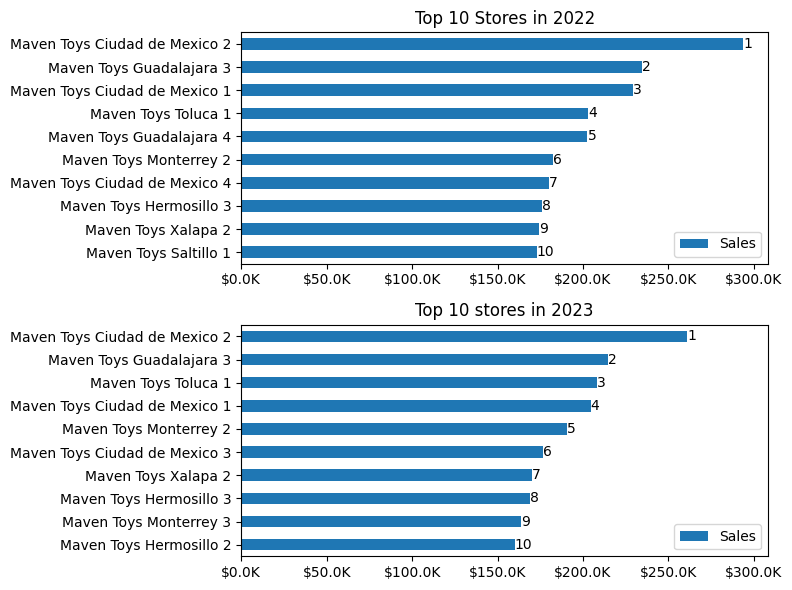

In [41]:
fig , ax = plt.subplots(2 , 1 ,figsize = (8 , 6))

top_10_2022.plot(kind= 'barh' , y = 'Sales'  ,x = 'Store_Name' ,  ax = ax[0])
ax[0].set_title('Top 10 Stores in 2022')
ax[0].invert_yaxis()
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${x/1000}K'))

for i, (sales, rank) in enumerate(zip(top_10_2022['Sales'], top_10_2022['Rank'])):        ### Ranking order
    ax[0].text(sales, i, f"{int(rank)}", va='center', ha='left')

top_10_2023.plot(kind= 'barh' , y = 'Sales' ,x = 'Store_Name' ,   ax = ax[1])
ax[1].set_title('Top 10 stores in 2023')
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${x/1000}K'))

for i , (sales , rank) in enumerate(zip(top_10_2023['Sales'] , top_10_2023['Rank'])):
    ax[1].text(sales , i , f'{rank}' , va = 'center' , ha = 'left')
    
fig.tight_layout()

We can see that Maven Toys Ciudad de Mexico 2 is Top 1 by Sales in 2022 and 2023. 

we congrat the performace of that store, Maven and all stuff working at Maven Toys Ciudad de Mexico 2.

In [42]:
top_10 = top_10.copy()
top_10['Rank'] = top_10['Sales'].rank(ascending= False , method= 'dense').astype(int)

top_10

,Sales,Profit,Rank
Store_Name,,,
Maven Toys Ciudad de Mexico 2,554553.43,169856.0,1
Maven Toys Guadalajara 3,449354.91,121571.0,2
Maven Toys Ciudad de Mexico 1,433556.21,111296.0,3
Maven Toys Toluca 1,411157.32,104612.0,4
Maven Toys Monterrey 2,372998.82,106783.0,5
Maven Toys Guadalajara 4,348466.64,102178.0,6
Maven Toys Hermosillo 3,344846.64,98825.0,7
Maven Toys Xalapa 2,344307.04,88637.0,8
Maven Toys Ciudad de Mexico 3,337424.66,94021.0,9


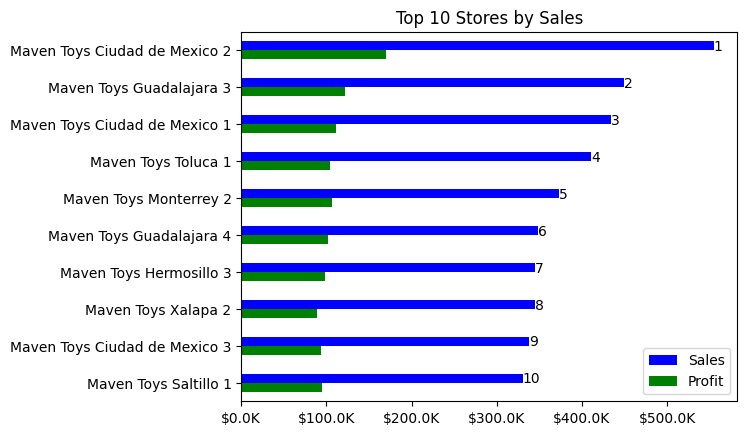

In [43]:
top_10.plot(kind= 'barh' , y = ['Sales' , 'Profit'] , color=['blue' , 'green'])
ax = plt.gca()
ax.set_title('Top 10 Stores by Sales')
ax.invert_yaxis()
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${x/1000}K'))
for i , (sales , rank) in enumerate(zip(top_10['Sales'] , top_10['Rank'])):
    ax.text(sales , i , f'{rank}' , ha = 'left')

In [44]:
df1 = df.copy()

In [45]:
median_sales = stores_sales['Sales'].median()

median_sales

np.float64(270882.395)

In [46]:
mean_sales = stores_sales['Sales'].mean()

mean_sales

np.float64(288891.447)

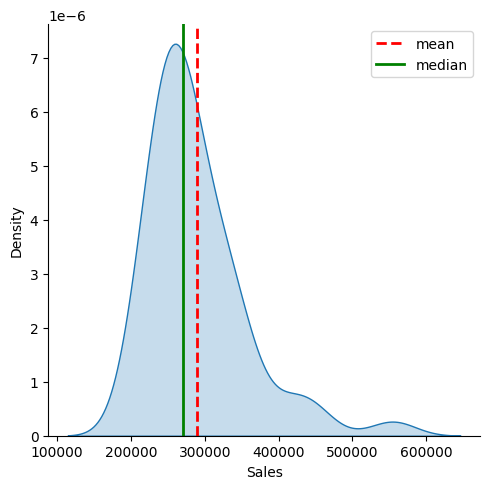

In [47]:


sns.displot(stores_sales , x = 'Sales' , kind = 'kde' , fill = True)
plt.axvline(mean_sales , color = 'red' , linewidth = 2 , linestyle = '--' , label = 'mean')
plt.axvline(median_sales , color = 'green' , linewidth = 2 , linestyle = '-' , label = 'median')
plt.legend()

<Axes: xlabel='Sales'>

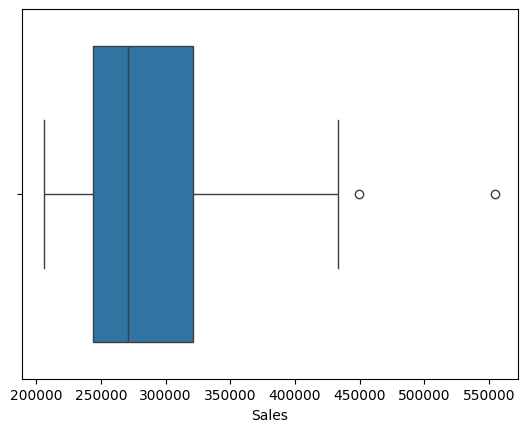

In [48]:
sns.boxplot(stores_sales , x = 'Sales' , fill= True)

The sale distribution is right skewed. So, we use median instead mean to compare value.

In [49]:
meand_profit = stores_sales['Profit'].mean()

In [50]:
median_profit = stores_sales['Profit'].median()

In [51]:
stores_sales['Sales_Status'] = stores_sales['Sales'].apply(lambda x:'high' if x > median_sales else 'low')

In [52]:
stores_sales['Profit_Status'] = stores_sales['Profit'].apply(lambda x: 'high' if x > median_profit else 'low')

In [53]:
stores_sales

,Sales,Profit,Sales_Status,Profit_Status
Store_Name,,,,
Maven Toys Ciudad de Mexico 2,554553.43,169856.0,high,high
Maven Toys Guadalajara 3,449354.91,121571.0,high,high
Maven Toys Ciudad de Mexico 1,433556.21,111296.0,high,high
Maven Toys Toluca 1,411157.32,104612.0,high,high
Maven Toys Monterrey 2,372998.82,106783.0,high,high
Maven Toys Guadalajara 4,348466.64,102178.0,high,high
Maven Toys Hermosillo 3,344846.64,98825.0,high,high
Maven Toys Xalapa 2,344307.04,88637.0,high,high
Maven Toys Ciudad de Mexico 3,337424.66,94021.0,high,high


In [54]:
hight_sales_low_profit = stores_sales[(stores_sales['Sales_Status'] =='high') & (stores_sales['Profit_Status'] == 'low')]

hight_sales_low_profit

,Sales,Profit,Sales_Status,Profit_Status
Store_Name,,,,
Maven Toys Puebla 2,282616.87,75082.0,high,low
Maven Toys Monterrey 1,277959.14,73985.0,high,low
Maven Toys Santiago 1,277598.14,72922.0,high,low
Maven Toys Guanajuato 3,276212.56,67495.0,high,low


In [55]:
low_sales_high_profit = stores_sales[(stores_sales['Sales_Status'] =='low') & (stores_sales['Profit_Status'] == 'high')]

In [56]:
low_sales_high_profit

,Sales,Profit,Sales_Status,Profit_Status
Store_Name,,,,
Maven Toys Chihuahua 2,268704.74,77263.0,low,high
Maven Toys Puebla 3,267559.55,78670.0,low,high
Maven Toys Puebla 1,258533.87,75942.0,low,high
Maven Toys Hermosillo 1,235115.18,76788.0,low,high


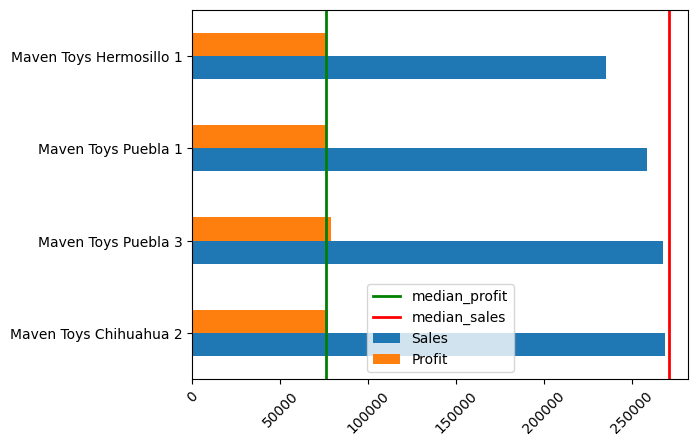

In [57]:
low_sales_high_profit.plot(kind= 'barh' , y =['Sales' , 'Profit'])
plt.xticks(rotation = 45)
plt.axvline(median_profit , linewidth = 2 , color = 'green' , label = 'median_profit')
plt.axvline(median_sales , linewidth = 2 , color = 'red' , label = 'median_sales')
plt.ylabel('')
plt.legend()

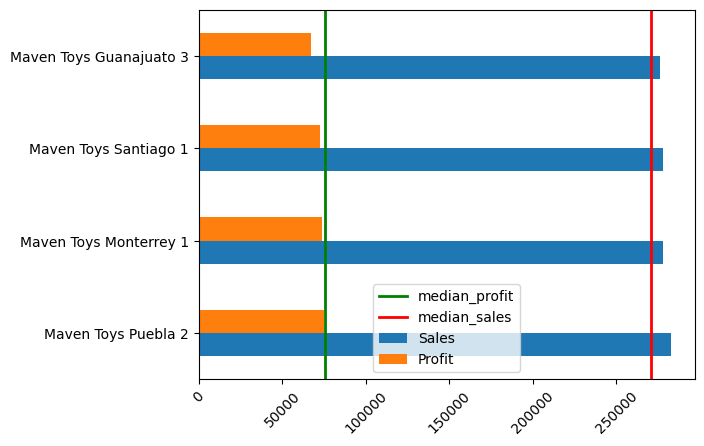

In [58]:
hight_sales_low_profit.plot(kind= 'barh' , y =['Sales' , 'Profit'])
plt.xticks(rotation = 45)
plt.axvline(median_profit , linewidth = 2 , color = 'green' , label = 'median_profit')
plt.axvline(median_sales , linewidth = 2 , color = 'red' , label = 'median_sales')
plt.ylabel('')
plt.legend()

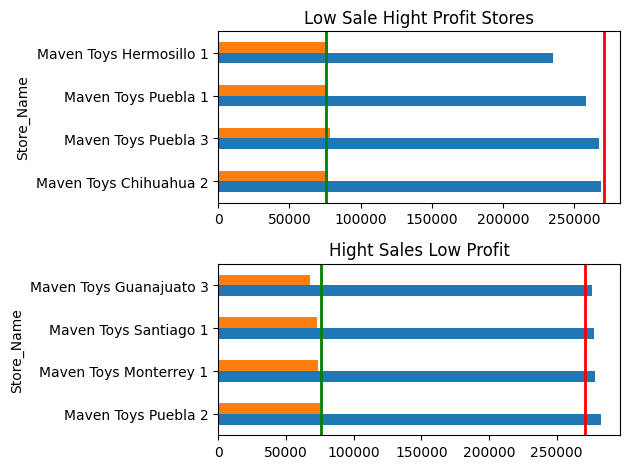

In [59]:
fig, ax = plt.subplots(2 , 1)
low_sales_high_profit.plot(kind= 'barh' , y =['Sales' , 'Profit'] , ax = ax[0])
ax[0].axvline(median_profit , linewidth = 2 , color = 'green' , label = 'median_profit')
ax[0].axvline(median_sales , linewidth = 2 , color = 'red' , label = 'median_sales')
ax[0].set_title('Low Sale Hight Profit Stores')
ax[0].legend().remove()

hight_sales_low_profit.plot(kind= 'barh' , y = ['Sales' , 'Profit'] , ax = ax[1])
ax[1].axvline(median_profit , linewidth = 2 , color = 'green' , label = 'median_profit')
ax[1].axvline(median_sales , linewidth = 2 , color = 'red' , label = 'median_sales')
ax[1].set_title('Hight Sales Low Profit')
ax[1].legend().remove()
fig.tight_layout()

In [60]:
store_pd_cate = pd.pivot_table(df , index= 'Store_Name' , columns='Product_Category' , aggfunc='size')

In [61]:
store_pd_cate.loc[low_sales_high_profit.index]

Product_Category,Art & Crafts,Electronics,Games,Sports & Outdoors,Toys
Store_Name,,,,,
Maven Toys Chihuahua 2,4291,1101,3564,3848,3776
Maven Toys Puebla 3,3810,2110,2517,1688,4743
Maven Toys Puebla 1,4149,2503,3856,2011,3257
Maven Toys Hermosillo 1,4024,2498,2774,2020,3948


In [62]:
store_pd_cate.loc[hight_sales_low_profit.index]

Product_Category,Art & Crafts,Electronics,Games,Sports & Outdoors,Toys
Store_Name,,,,,
Maven Toys Puebla 2,5410,1341,2308,2643,5062
Maven Toys Monterrey 1,4715,2004,2438,2160,4381
Maven Toys Santiago 1,5098,1662,2691,1838,4822
Maven Toys Guanajuato 3,3781,1068,2514,2537,4669


We can see two groups 'High Sales Low Profit' and 'Low Sales High Profit'. 

In Low Sales High Profit group, we see that they can sell more Games and Sport & Outdoors products than High Sales High Profit.

In High Sales Low Profit group, we see that they can sell more Art& Craft products  and Toys products than Low Sales High Profit.

Based on this results, we should promote the product based on their sales to get our target value. 

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sale_ID           829262 non-null  int64         
 1   Date              829262 non-null  datetime64[ns]
 2   Store_ID          829262 non-null  int64         
 3   Product_ID        829262 non-null  int64         
 4   Units             829262 non-null  int64         
 5   Product_Name      829262 non-null  object        
 6   Product_Category  829262 non-null  object        
 7   Product_Cost      829262 non-null  float64       
 8   Product_Price     829262 non-null  float64       
 9   Store_Name        829262 non-null  object        
 10  Store_City        829262 non-null  object        
 11  Store_Location    829262 non-null  object        
 12  Store_Open_Date   829262 non-null  object        
 13  month_name        829262 non-null  object        
 14  Prof

<Axes: xlabel='Sales', ylabel='Profit'>

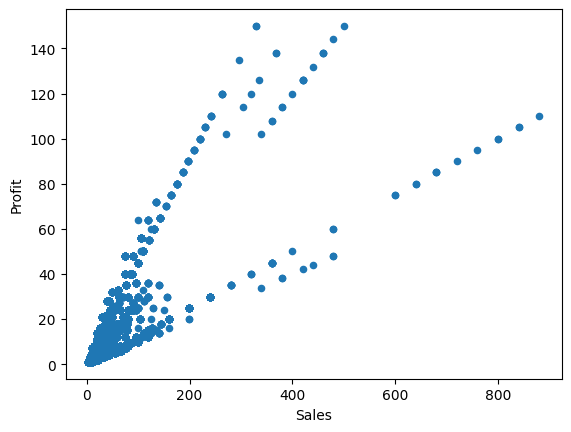

In [64]:
df.plot(kind= 'scatter' , x = 'Sales' , y = 'Profit')

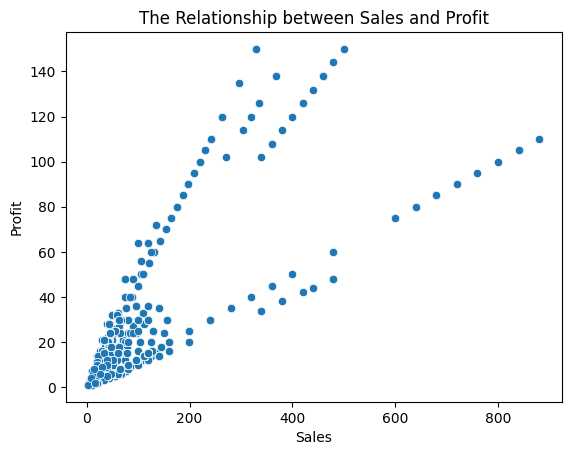

In [65]:
sns.scatterplot(df , x = 'Sales' , y = 'Profit')
plt.title('The Relationship between Sales and Profit')
ax = plt.gca()

In the graph, we can see that Profit does not rise whenever Sales value rise.

This is our stores are selling different product categories.

We see the highest revenue is above $ 140 and the Sales values is between 200 and 400. 

Analysis on Each Products

In [66]:
product_sales = df.groupby(['Product_Name' , 'Product_Category']).agg(Sales = ('Sales' , 'sum'),
                                                                      Profit = ('Profit', 'sum')  ).sort_values('Sales' , ascending=False)

In [67]:
top10_products = product_sales.head(10)

top10_products

,,Sales,Profit
Product_Name,Product_Category,,
Lego Bricks,Toys,2388882.63,298685.0
Colorbuds,Electronics,1564476.32,834944.0
Magic Sand,Art & Crafts,968962.02,121196.0
Action Figure,Toys,926748.42,347748.0
Rubik's Cube,Games,912983.28,91344.0
Deck Of Cards,Games,587397.66,252102.0
Splash Balls,Sports & Outdoors,541629.52,60248.0
Nerf Gun,Sports & Outdoors,530594.57,132715.0
Animal Figures,Toys,507766.11,117267.0


The Lego Bricks are the best selling products and the profit maker. 

In top 10 best selling products, we can see that there are 3 products(toy category),

3 products(Sports & Outdoors categroy) , 2 products(Games) , 1 product(Art & Crafts category)

and 1 product(Electonics category).

we should promote the Lego Bricks to matain the sales  and colorbuds is the hightest profit margin in top 10 products.

In [68]:
product_sales['Profit_margin'] = product_sales['Profit'] / product_sales['Sales'] * 100

In [69]:
product_sales.sort_values('Profit_margin' , ascending= False).head(10)

,,Sales,Profit,Profit_margin
Product_Name,Product_Category,,,
Jenga,Games,130409.46,91378.0,70.070070
Mini Basketball Hoop,Sports & Outdoors,66148.53,42352.0,64.025610
Playfoam,Art & Crafts,45696.42,29106.0,63.694268
Plush Pony,Toys,109705.12,60368.0,55.027514
Colorbuds,Electronics,1564476.32,834944.0,53.368913
Barrel O' Slime,Art & Crafts,365735.37,183326.0,50.125313
Uno Card Game,Games,21652.90,10840.0,50.062578
Mr. Potatohead,Toys,85963.95,43025.0,50.050050
Etch A Sketch,Art & Crafts,255406.32,121680.0,47.641734


In order to Profit margin, Jenga is the highest profit margin and colorbuds(top 10 products) is fifht highest profit margin.meand_profit



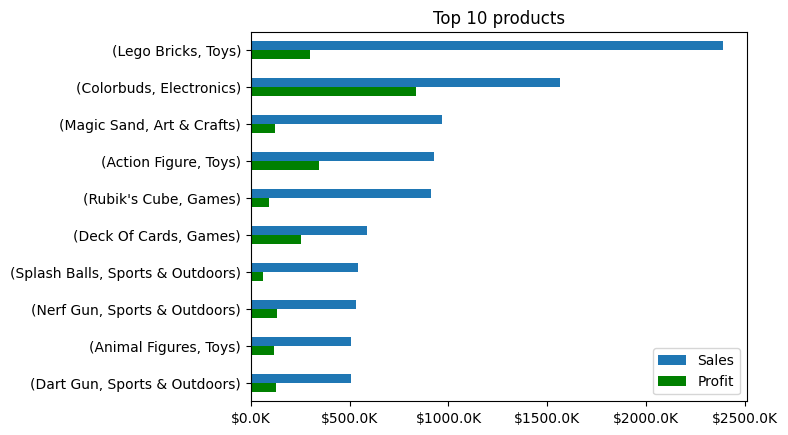

In [70]:
top10_products.plot(kind='barh' , y = ['Sales' , 'Profit'] ,color = ['tab:blue' , 'Green'] )
plt.title('Top 10 products')
plt.ylabel('')
ax = plt.gca()
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${x/1000}K'))


we can see clearly that although Lego Bricks are highest Sales , we get low profit from it.

Color buds is not only highest Sales product but also the highest profit margin in top 10 best selling products.

We should promote on Electronics products to get highest profit and highest Sales.

And also, we matain the current suitation of other products.

Text(0.5, -195.7777777777778, '')

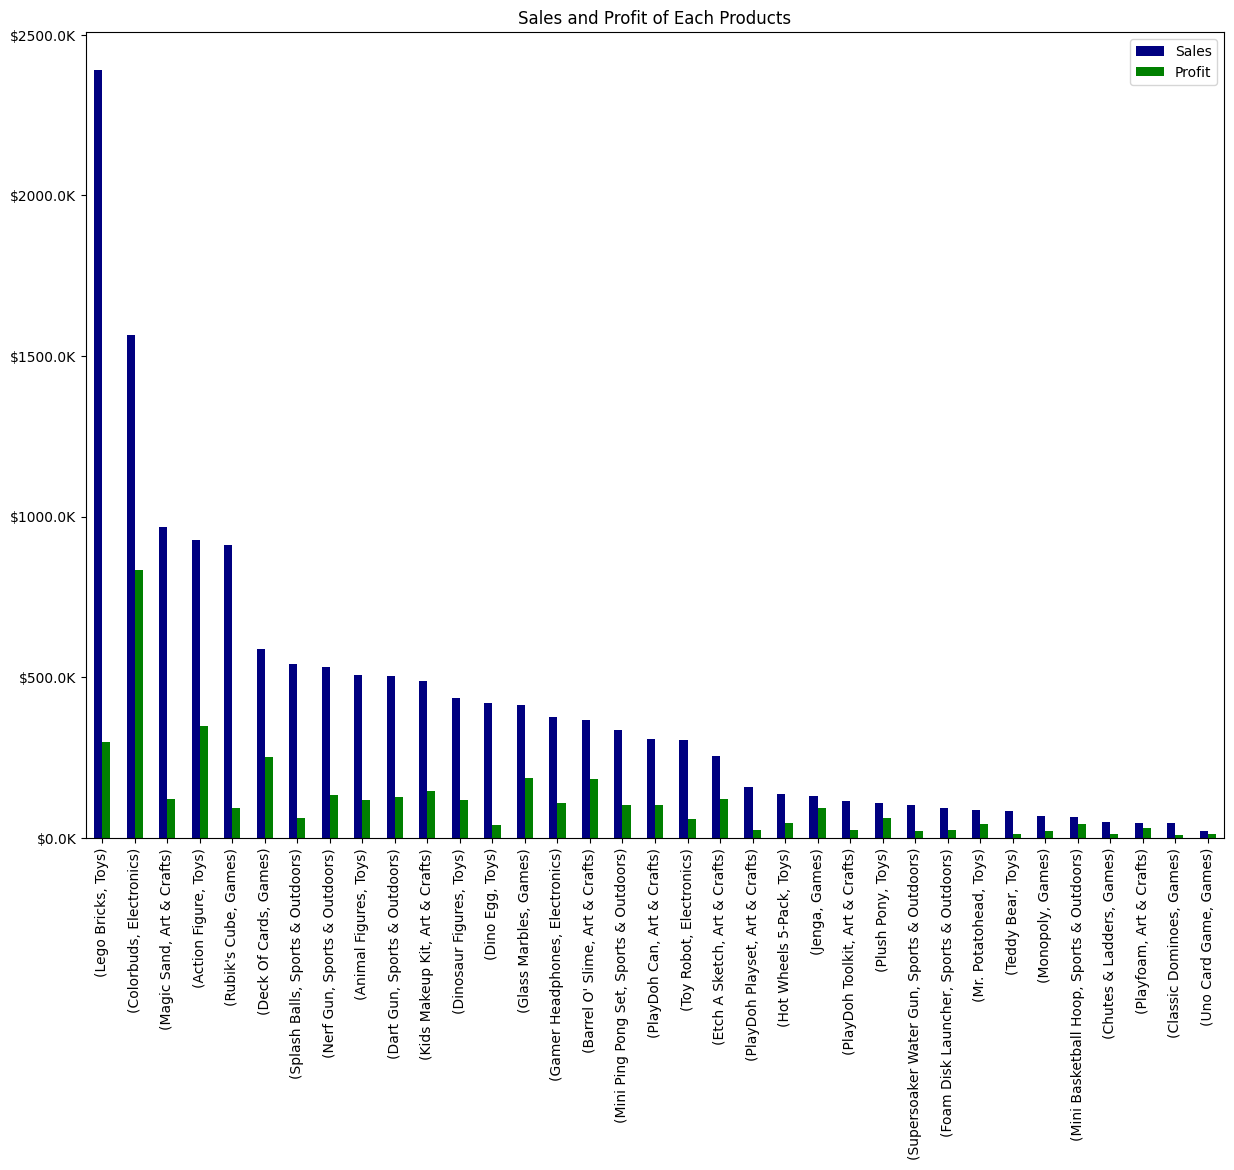

In [71]:
fig , ax= plt.subplots(figsize = (12 , 12))

product_sales.plot(kind= 'bar' , y = ['Sales' , 'Profit'] , color = ['navy' ,'green'] , ax=ax)
plt.title('Sales and Profit of Each Products')
plt.tight_layout()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x , _:f'${x/1000}K'))
ax.set_xlabel('')

We can see that the colorbuds is the only products which get the profit greater than $ 500k.

Acton figures are the second highest profit maker. We should promote them to sell more.


In [72]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Store_ID       1593 non-null   int64
 1   Product_ID     1593 non-null   int64
 2   Stock_On_Hand  1593 non-null   int64
dtypes: int64(3)
memory usage: 37.5 KB


In [73]:
sales_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Sale_ID           829262 non-null  int64 
 1   Date              829262 non-null  object
 2   Store_ID          829262 non-null  int64 
 3   Product_ID        829262 non-null  int64 
 4   Units             829262 non-null  int64 
 5   Product_Name      829262 non-null  object
 6   Product_Category  829262 non-null  object
 7   Product_Cost      829262 non-null  object
 8   Product_Price     829262 non-null  object
dtypes: int64(4), object(5)
memory usage: 56.9+ MB


In [74]:
inventory

,Store_ID,Product_ID,Stock_On_Hand
0,1,1,27
1,1,2,0
2,1,3,32
3,1,4,6
4,1,5,0
...,...,...,...
1588,50,31,18
1589,50,32,9
1590,50,33,1
1591,50,34,17


We need to analysis on inventory. We need to merge inventory table.

But, we can't merge the whole data causing memory error.

To solve this problem, we need to aggregation first.

In [75]:
sales_agg = df.groupby(['Product_Name','Product_ID'], as_index=False).agg(
    Total_Units=('Units', 'sum'),
    Total_Revenue=('Sales', 'sum')
)
merged = pd.merge(sales_agg, inventory, on='Product_ID', how='left')

In [76]:
merged

,Product_Name,Product_ID,Total_Units,Total_Revenue,Store_ID,Stock_On_Hand
0,Action Figure,1,57958,926748.42,1,27
1,Action Figure,1,57958,926748.42,2,0
2,Action Figure,1,57958,926748.42,3,17
3,Action Figure,1,57958,926748.42,4,2
4,Action Figure,1,57958,926748.42,5,8
...,...,...,...,...,...,...
1588,Uno Card Game,35,2710,21652.90,41,10
1589,Uno Card Game,35,2710,21652.90,42,13
1590,Uno Card Game,35,2710,21652.90,48,3
1591,Uno Card Game,35,2710,21652.90,49,19


In [77]:
out_of_stock_pd = merged[merged['Stock_On_Hand']== 0 ]

In [78]:
out_of_stock_pd

,Product_Name,Product_ID,Total_Units,Total_Revenue,Store_ID,Stock_On_Hand
1,Action Figure,1,57958,926748.42,2,0
5,Action Figure,1,57958,926748.42,6,0
12,Action Figure,1,57958,926748.42,13,0
38,Action Figure,1,57958,926748.42,39,0
43,Action Figure,1,57958,926748.42,44,0
...,...,...,...,...,...,...
1486,Teddy Bear,33,6416,83343.84,19,0
1511,Teddy Bear,33,6416,83343.84,44,0
1515,Teddy Bear,33,6416,83343.84,48,0
1518,Toy Robot,34,11749,305356.51,1,0


In [79]:
pd_inventory = pd.merge(products , inventory , on = 'Product_ID')

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sale_ID           829262 non-null  int64         
 1   Date              829262 non-null  datetime64[ns]
 2   Store_ID          829262 non-null  int64         
 3   Product_ID        829262 non-null  int64         
 4   Units             829262 non-null  int64         
 5   Product_Name      829262 non-null  object        
 6   Product_Category  829262 non-null  object        
 7   Product_Cost      829262 non-null  float64       
 8   Product_Price     829262 non-null  float64       
 9   Store_Name        829262 non-null  object        
 10  Store_City        829262 non-null  object        
 11  Store_Location    829262 non-null  object        
 12  Store_Open_Date   829262 non-null  object        
 13  month_name        829262 non-null  object        
 14  Prof

In [81]:
inventory

,Store_ID,Product_ID,Stock_On_Hand
0,1,1,27
1,1,2,0
2,1,3,32
3,1,4,6
4,1,5,0
...,...,...,...
1588,50,31,18
1589,50,32,9
1590,50,33,1
1591,50,34,17


We want to check the inventory status. 

But we don't need all time. We need recent sales and recent month.

Otherwise, our data load is to millions.

In [82]:
df_23 = df[df['Year'] == 2023]

In [83]:
last_date = df_23['Date'].max()

last_date

Timestamp('2023-09-30 00:00:00')

In [84]:
cut_date = last_date - pd.DateOffset(days=120)

In [85]:
cut_date

Timestamp('2023-06-02 00:00:00')

In [86]:
recent_sales = df_23[df_23['Date'] > cut_date]

In [87]:
recent_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175433 entries, 653829 to 829261
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sale_ID           175433 non-null  int64         
 1   Date              175433 non-null  datetime64[ns]
 2   Store_ID          175433 non-null  int64         
 3   Product_ID        175433 non-null  int64         
 4   Units             175433 non-null  int64         
 5   Product_Name      175433 non-null  object        
 6   Product_Category  175433 non-null  object        
 7   Product_Cost      175433 non-null  float64       
 8   Product_Price     175433 non-null  float64       
 9   Store_Name        175433 non-null  object        
 10  Store_City        175433 non-null  object        
 11  Store_Location    175433 non-null  object        
 12  Store_Open_Date   175433 non-null  object        
 13  month_name        175433 non-null  object        
 14  Prof

In [88]:
sales_120 = recent_sales.groupby(['Product_Name' , 'Product_ID']).agg(Units_120d = ('Units' , 'sum')).reset_index()

In [89]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Store_ID       1593 non-null   int64
 1   Product_ID     1593 non-null   int64
 2   Stock_On_Hand  1593 non-null   int64
dtypes: int64(3)
memory usage: 37.5 KB


In [90]:
inventry_agg = inventory.groupby('Product_ID').agg(Total_Stock = ('Stock_On_Hand' , 'sum')).reset_index()

In [91]:
sale_invt = pd.merge(sales_120 , inventry_agg , on = 'Product_ID')

In [92]:
sale_invt['Units_120d'] = sale_invt['Units_120d'].fillna(value= 0 )

In [93]:
sale_invt['Daily_sales'] = sale_invt['Units_120d'] / 120

In [94]:
sale_invt.sort_values('Daily_sales' , ascending= False , inplace= True)

In [95]:
sale_invt

,Product_Name,Product_ID,Units_120d,Total_Stock,Daily_sales
24,PlayDoh Can,25,25699,2129,214.158333
18,Magic Sand,19,20311,1922,169.258333
2,Barrel O' Slime,3,20202,1282,168.350000
7,Deck Of Cards,8,14169,2738,118.075000
8,Dino Egg,9,13131,649,109.425000
30,Splash Balls,31,12245,893,102.041667
5,Colorbuds,6,12138,1159,101.150000
17,Lego Bricks,18,11453,1118,95.441667
20,Mini Ping Pong Set,21,8136,974,67.800000
1,Animal Figures,2,8003,835,66.691667


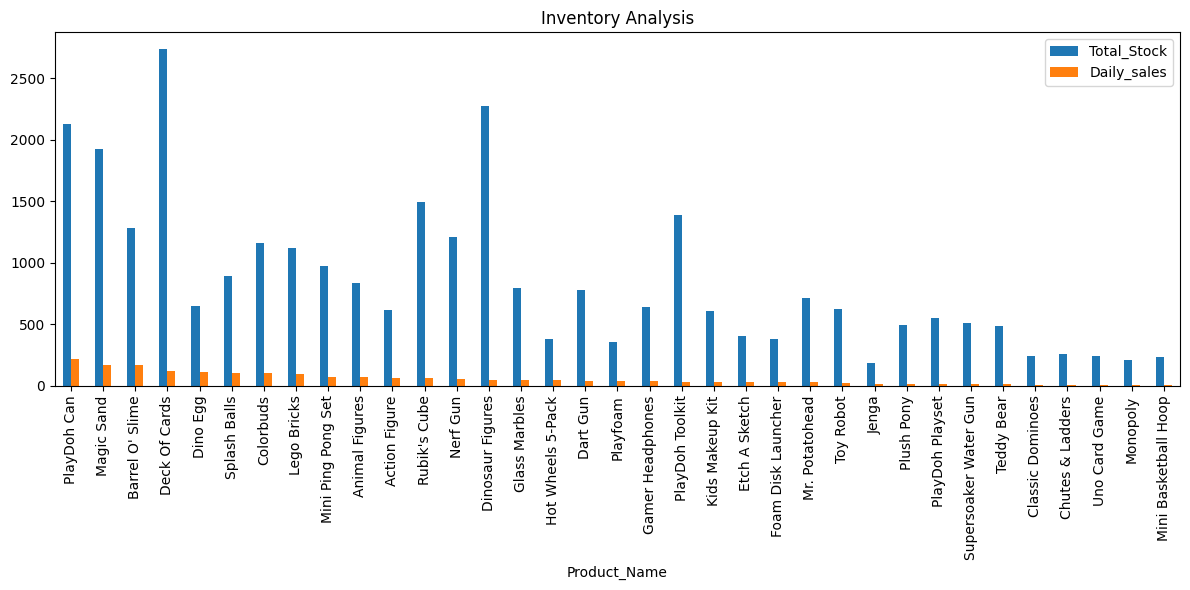

In [96]:
fig , ax = plt.subplots(figsize = (12 , 6))

sale_invt.plot(kind= 'bar' , x = 'Product_Name' , y = ['Total_Stock' , 'Daily_sales'] , ax = ax)
plt.title('Inventory Analysis')
plt.tight_layout()

We must to find dead products which mean no sale.

In [97]:
sale_invt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 24 to 19
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_Name  35 non-null     object 
 1   Product_ID    35 non-null     int64  
 2   Units_120d    35 non-null     int64  
 3   Total_Stock   35 non-null     int64  
 4   Daily_sales   35 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.6+ KB


In [98]:
sale_invt['Day_to_sell'] = sale_invt['Total_Stock']/sale_invt['Daily_sales']

In [99]:
sale_invt

,Product_Name,Product_ID,Units_120d,Total_Stock,Daily_sales,Day_to_sell
24,PlayDoh Can,25,25699,2129,214.158333,9.941243
18,Magic Sand,19,20311,1922,169.258333,11.355423
2,Barrel O' Slime,3,20202,1282,168.350000,7.615088
7,Deck Of Cards,8,14169,2738,118.075000,23.188651
8,Dino Egg,9,13131,649,109.425000,5.931003
30,Splash Balls,31,12245,893,102.041667,8.751327
5,Colorbuds,6,12138,1159,101.150000,11.458230
17,Lego Bricks,18,11453,1118,95.441667,11.713961
20,Mini Ping Pong Set,21,8136,974,67.800000,14.365782
1,Animal Figures,2,8003,835,66.691667,12.520305


We need to find products may be stock out.

At least, we must the time taken to reorder is 30 days.

In [100]:
red_condit_pd = sale_invt[sale_invt['Day_to_sell']  <= 10]

In [101]:
red_condit_pd

,Product_Name,Product_ID,Units_120d,Total_Stock,Daily_sales,Day_to_sell
24,PlayDoh Can,25,25699,2129,214.158333,9.941243
2,Barrel O' Slime,3,20202,1282,168.350000,7.615088
8,Dino Egg,9,13131,649,109.425000,5.931003
30,Splash Balls,31,12245,893,102.041667,8.751327
0,Action Figure,1,7638,614,63.650000,9.646504
14,Hot Wheels 5-Pack,15,5214,376,43.450000,8.653625


we see that PlayDoh Can is the highest dail sale products during 4 months. 

We may face stock out conditons with above products.

Dino Egg is 5 day left to be stock out. 

This is the red conditon.

We must reorder this product within 3 days to matain our customers.

In [102]:
dead_stock_conditon = sale_invt[sale_invt['Day_to_sell'] >  30].sort_values('Day_to_sell' , ascending= False)

In [103]:
dead_stock_conditon

,Product_Name,Product_ID,Units_120d,Total_Stock,Daily_sales,Day_to_sell
19,Mini Basketball Hoop,20,353,234,2.941667,79.546742
25,PlayDoh Playset,26,1299,550,10.825000,50.808314
31,Supersoaker Water Gun,32,1231,513,10.258333,50.008123
32,Teddy Bear,33,1176,483,9.800000,49.285714
9,Dinosaur Figures,10,5720,2272,47.666667,47.664336
28,Plush Pony,29,1374,497,11.450000,43.406114
26,PlayDoh Toolkit,27,3863,1387,32.191667,43.085685
34,Uno Card Game,35,683,241,5.691667,42.342606
3,Chutes & Ladders,4,796,255,6.633333,38.442211
21,Monopoly,22,666,207,5.550000,37.297297


Based on above data, we see that Mini Baseketball Hoop is our deat stock product. 

Its daily sales is 3. To tournover , it is 80 days taken.

We see something unsual that Dinosaur Figures's daily sales is the highest and it is in dead stock condition.

We should do something. 

In [104]:
import seaborn as sns

Text(0.5, 0, '')

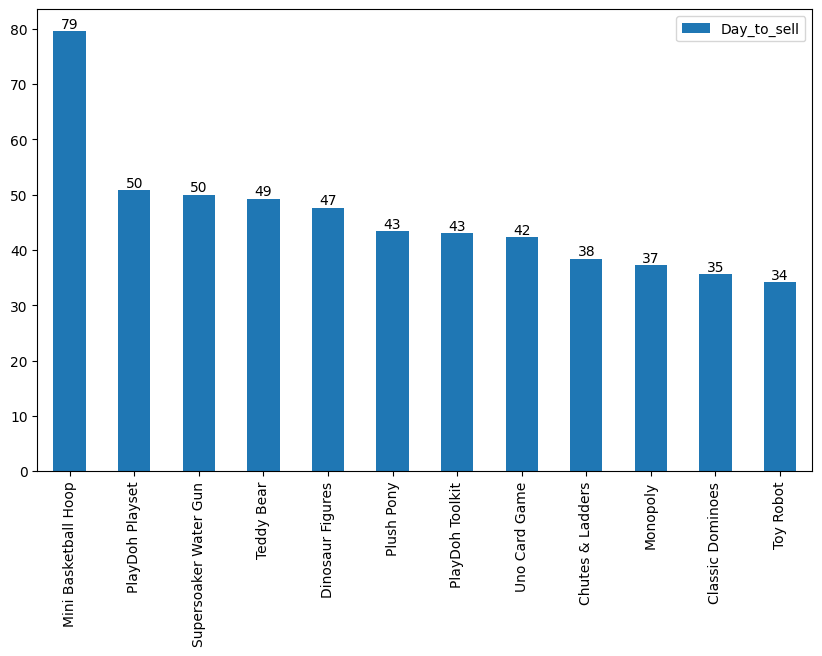

In [105]:
fig , ax = plt.subplots(figsize = (10 , 6))


dead_stock_conditon.plot(kind='bar' , x = 'Product_Name' , y = ['Day_to_sell'] , ax = ax)
for i , day in enumerate(dead_stock_conditon['Day_to_sell']):
    ax.text(i , day , f'{int(day)}' , ha = 'center' , va = 'bottom')
ax.set_xlabel('')

In [106]:
pd_cost = df_23.groupby(['Product_Name' , 'Product_ID' , 'Product_Cost']).agg(Total_units = ('Units' , 'sum')).reset_index()

pd_cost

,Product_Name,Product_ID,Product_Cost,Total_units
0,Action Figure,1,9.99,20923
1,Animal Figures,2,9.99,16809
2,Barrel O' Slime,3,1.99,61232
3,Chutes & Ladders,4,9.99,1897
4,Classic Dominoes,5,7.99,1951
5,Colorbuds,6,6.99,29156
6,Dart Gun,7,11.99,10248
7,Deck Of Cards,8,3.99,36484
8,Dino Egg,9,9.99,27111
9,Dinosaur Figures,10,10.99,12028


In [107]:
inv_sales = pd.merge(pd_cost , inventry_agg ,on = 'Product_ID')

In [108]:
inv_sales['Cost_good_sold'] = inv_sales['Total_units'] * inv_sales['Product_Cost']

In [113]:
inv_sales['inventory_cost'] = (inv_sales['Total_Stock'] * inv_sales['Product_Cost'])

In [116]:
inv_sales['turnover_estimate'] = inv_sales['Cost_good_sold'] / inv_sales['inventory_cost']

In [ ]:
inv_sales

,Product_Name,Product_ID,Product_Cost,Total_units,Total_Stock,Cost_good_sold,Invetory_Cost,avg_inventory_cost,turnover_estimate
0,Action Figure,1,9.99,20923,614,209020.77,6133.86,3066.930,34.076547
1,Animal Figures,2,9.99,16809,835,167921.91,8341.65,4170.825,20.130539
2,Barrel O' Slime,3,1.99,61232,1282,121851.68,2551.18,1275.590,47.762871
3,Chutes & Ladders,4,9.99,1897,255,18951.03,2547.45,1273.725,7.439216
4,Classic Dominoes,5,7.99,1951,241,15588.49,1925.59,962.795,8.095436
5,Colorbuds,6,6.99,29156,1159,203800.44,8101.41,4050.705,25.156169
6,Dart Gun,7,11.99,10248,776,122873.52,9304.24,4652.120,13.206186
7,Deck Of Cards,8,3.99,36484,2738,145571.16,10924.62,5462.310,13.325055
8,Dino Egg,9,9.99,27111,649,270838.89,6483.51,3241.755,41.773498
9,Dinosaur Figures,10,10.99,12028,2272,132187.72,24969.28,12484.640,5.294014


In [117]:
inv_sales[inv_sales['turnover_estimate'] < 5]

,Product_Name,Product_ID,Product_Cost,Total_units,Total_Stock,Cost_good_sold,avg_inventory_cost,inventory_cost,turnover_estimate
19,Mini Basketball Hoop,20,8.99,910,234,8180.90,1051.83,2103.66,3.888889
25,PlayDoh Playset,26,20.99,2666,550,55959.34,5772.25,11544.50,4.847273


We can see our turnover estimate is greater 12. 

But, we found that two product are less than 5 times inventory turnover estimate.

So, we should care reorder on time to avoid facing stock out.

Our stores are performing good socres. 

Analysis on monthly trend 

In [118]:
df_22= df[df['Year'] == 2022]

In our datasets, there are 2 Year periods. 

We should clarify the trend with time series analysis.

In [119]:
df_23.info()

<class 'pandas.core.frame.DataFrame'>
Index: 408417 entries, 420845 to 829261
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sale_ID           408417 non-null  int64         
 1   Date              408417 non-null  datetime64[ns]
 2   Store_ID          408417 non-null  int64         
 3   Product_ID        408417 non-null  int64         
 4   Units             408417 non-null  int64         
 5   Product_Name      408417 non-null  object        
 6   Product_Category  408417 non-null  object        
 7   Product_Cost      408417 non-null  float64       
 8   Product_Price     408417 non-null  float64       
 9   Store_Name        408417 non-null  object        
 10  Store_City        408417 non-null  object        
 11  Store_Location    408417 non-null  object        
 12  Store_Open_Date   408417 non-null  object        
 13  month_name        408417 non-null  object        
 14  Prof

In [120]:
monthly_sales_22 = df_22.groupby('month_name').agg(Total_Units = ('Units' , 'sum'),
                                Total_Sales = ('Sales' ,'sum'),
                                Total_Profit = ('Profit' , 'sum')).reset_index()

In [121]:
monthly_sales_22['month_num'] = pd.to_datetime(monthly_sales_22['month_name'], format=('%b')).dt.month

In [122]:
monthly_sales_22.sort_values('month_num' , ascending= True, inplace= True)

In [123]:
monthly_sales_22

,month_name,Total_Units,Total_Sales,Total_Profit,month_num
4,Jan,38009,542554.91,167126.0,1
3,Feb,36935,541351.65,161861.0,2
7,Mar,39981,589485.19,173992.0,3
0,Apr,47102,681072.98,190099.0,4
8,May,46910,672369.90,186894.0,5
6,Jun,47178,661980.22,189815.0,6
5,Jul,46177,556034.23,176922.0,7
1,Aug,39927,489422.73,158931.0,8
11,Sep,42196,585844.04,166397.0,9
10,Oct,47861,623874.39,178799.0,10


In [124]:
monthly_sales_23 = df_23.groupby('month_name').agg(Total_Units = ('Units' , 'sum'),
                                Total_Sales = ('Sales' ,'sum'),
                                Total_Profit = ('Profit' , 'sum')).reset_index()

In [125]:
monthly_sales_23['month_num'] = pd.to_datetime(monthly_sales_23['month_name'], format=('%b')).dt.month

In [126]:
monthly_sales_23.sort_values('month_num' , ascending= True, inplace= True)

In [127]:
monthly_sales_23

,month_name,Total_Units,Total_Sales,Total_Profit,month_num
3,Jan,56478,747196.22,205074.0,1
2,Feb,54581,722632.19,189314.0,2
6,Mar,69336,883515.64,231909.0,3
0,Apr,65593,827691.07,215096.0,4
7,May,63851,825319.49,210347.0,5
5,Jun,64275,808299.25,207212.0,6
4,Jul,63614,828348.86,209807.0,7
1,Aug,51193,660877.07,175038.0,8
8,Sep,52152,658194.48,180445.0,9


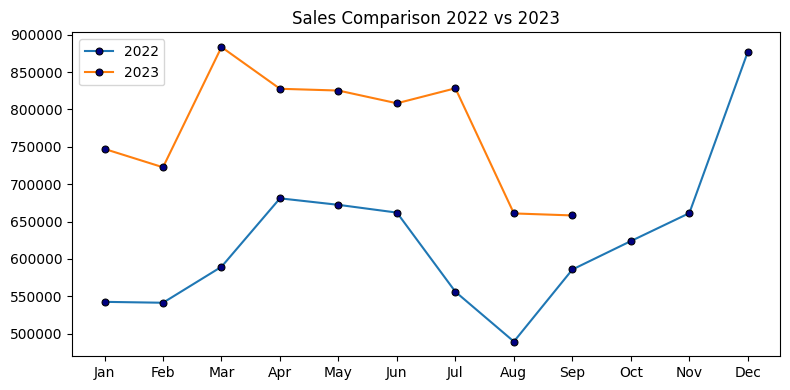

In [130]:

fig , ax = plt.subplots(figsize = (8 , 4))



sns.lineplot(monthly_sales_22 , x = 'month_name' , y = 'Total_Sales' , ax = ax , marker = 'o' , 
             markersize = 5 , markeredgecolor = 'black' , markerfacecolor = 'navy' , label = 2022)


sns.lineplot(monthly_sales_23 , x = 'month_name' , y = 'Total_Sales' , ax = ax , marker = 'o' , 
             markersize = 5 , markeredgecolor = 'black' , markerfacecolor = 'navy' , label = 2023)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Sales Comparison 2022 vs 2023')
fig.tight_layout()

We can see that our sales always down on August and is rerising on Q4.

In 2023, our sales are greater than sales in 2022 but we think price inflation.

In [131]:
df_23['Weekday'] = df_23['Date'].dt.day_name()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24984\1780932587.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_23['Weekday'] = df_23['Date'].dt.day_name()


In [132]:
weekday_sale = df_23.groupby('Weekday').agg(Total_Sales = ('Sales' ,'sum') , 
                             Total_units = ('Units' , 'sum')).reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

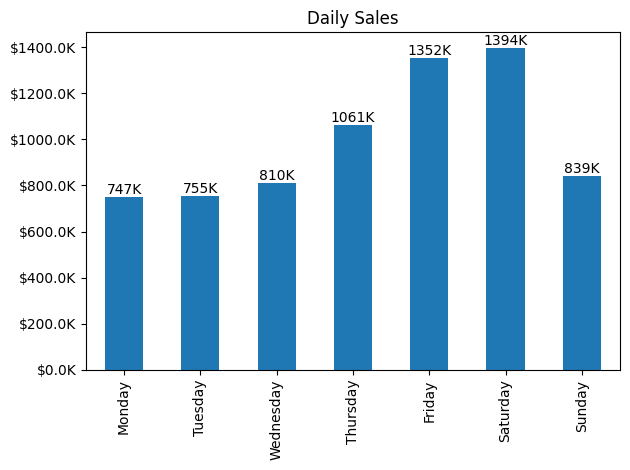

In [133]:
weekday_sale.plot(kind = 'bar' , y = 'Total_Sales')
plt.title('Daily Sales')

for i , sale in enumerate(weekday_sale['Total_Sales']):
    plt.text(i , sale, f'{int(sale/1000)}K' , va = 'bottom' , ha = 'center')
    
ax = plt.gca()
ax.set_ylabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000}K'))  
ax.set_xlabel('')  
ax.legend().remove()
    
plt.tight_layout()

In [134]:
Weekend = ['Saturday' , 'Sunday']


In [135]:
df_23['Day_type'] = df_23['Weekday'].apply(lambda x: 'weekend' if x in (Weekend) else 'Weekday')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24984\2606211917.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_23['Day_type'] = df_23['Weekday'].apply(lambda x: 'weekend' if x in (Weekend) else 'Weekday')


In [136]:
Weekday_vs_weekend = df_23.groupby('Day_type').agg(Total_sale = ('Sales' , 'sum') , Total_Units = ('Units' , 'sum'))

In [137]:
total_sale_23 = df_23['Sales'].sum()

In [138]:
Weekday_vs_weekend['sale_percent'] = (Weekday_vs_weekend['Total_sale']/ total_sale_23) * 100 

<Axes: xlabel='Day_type'>

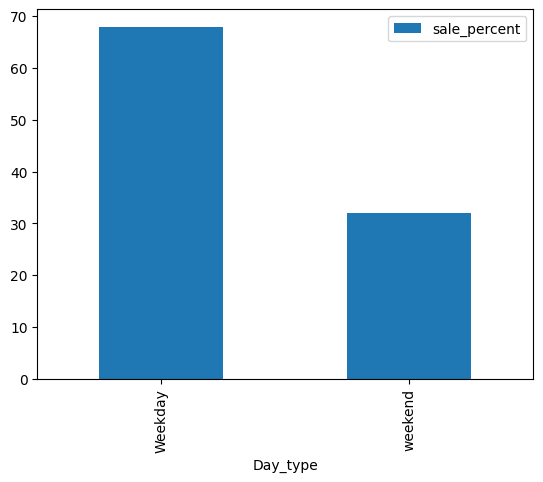

In [139]:
Weekday_vs_weekend.plot(kind= 'bar' , y = 'sale_percent')

Based on above graph and data, customer is more consuming in weekend because they come to our store with their child and 

they buy everything their child want.

In [140]:
Weekday_vs_weekend

,Total_sale,Total_Units,sale_percent
Day_type,,,
Weekday,4728129.74,367926,67.912659
weekend,2233944.53,173147,32.087341


In [141]:
Weekday_vs_weekend['avg_weeday_sale'] = Weekday_vs_weekend.loc['Weekday' , 'Total_sale']/ 5

In [142]:
Weekday_vs_weekend['avg_weekend_sale']  = Weekday_vs_weekend.loc['weekend' , 'Total_sale'] / 2

In [144]:
Weekday_vs_weekend.drop(columns=['avg_weeday_sale' , 'avg_weekend_sale'] , inplace= True)

In [145]:
Weekday_vs_weekend

,Total_sale,Total_Units,sale_percent
Day_type,,,
Weekday,4728129.74,367926,67.912659
weekend,2233944.53,173147,32.087341


In [146]:
def avg_per_day(row):
    if row['Day_type']== 'Weekday':
        return row['Total_sale'] / 5
    else:  # Weekend
        return row['Total_sale'] / 2

In [147]:
Weekday_vs_weekend.reset_index(inplace= True)

In [148]:
Weekday_vs_weekend['avg_sale'] = Weekday_vs_weekend.apply(avg_per_day , axis = 1)

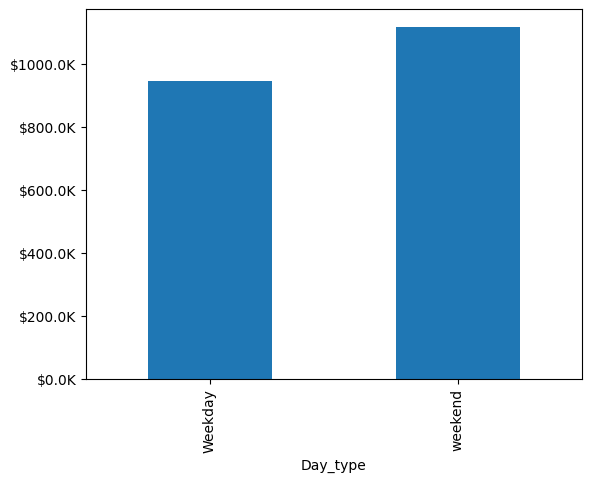

In [149]:
Weekday_vs_weekend.plot(kind= 'bar' ,x = 'Day_type' ,  y ='avg_sale')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000}K'))
ax.legend().remove()

Product Categorical Analysis

In [150]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sale_ID           829262 non-null  int64         
 1   Date              829262 non-null  datetime64[ns]
 2   Store_ID          829262 non-null  int64         
 3   Product_ID        829262 non-null  int64         
 4   Units             829262 non-null  int64         
 5   Product_Name      829262 non-null  object        
 6   Product_Category  829262 non-null  object        
 7   Product_Cost      829262 non-null  float64       
 8   Product_Price     829262 non-null  float64       
 9   Store_Name        829262 non-null  object        
 10  Store_City        829262 non-null  object        
 11  Store_Location    829262 non-null  object        
 12  Store_Open_Date   829262 non-null  object        
 13  month_name        829262 non-null  object        
 14  Prof

In [151]:
category_sale = df1.groupby('Product_Category').agg(Total_Sale = ('Sales' , 'sum') , 
                                    Total_Units = ('Units' , 'sum') , 
                                    Total_Profit = ('Profit' , 'sum')).sort_values('Total_Sale' , ascending= False)

In [152]:
category_sale['Profit_margin'] = category_sale['Total_Profit'] / category_sale['Total_Sale']

In [153]:
category_sale

,Total_Sale,Total_Units,Total_Profit,Profit_margin
Product_Category,,,,
Toys,5093241.00,267200,1079527.0,0.211953
Art & Crafts,2705364.26,325574,753354.0,0.278467
Electronics,2246771.25,134075,1001437.0,0.445723
Games,2226836.27,194673,673993.0,0.302668
Sports & Outdoors,2172359.57,169043,505718.0,0.232797


Text(0, 0.5, '')

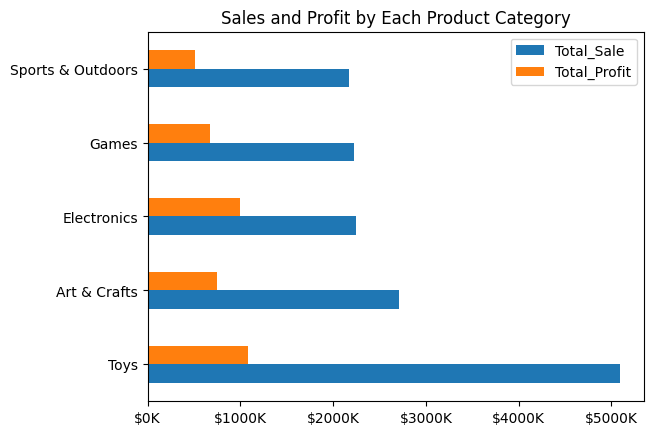

In [161]:
category_sale.plot(kind= 'barh' , y = ['Total_Sale' , 'Total_Profit'])
plt.title('Sales and Profit by Each Product Category')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _:f'${int(x/1000)}K'))
ax.set_xlabel('')
ax.set_ylabel('')


Toys are the highest sale and profit but we get `$ 21 `
whenever we sell  ` $ 100` Toys.

Electronics is the highest profit margin;it is about 45% which mean we get `45 $ `
whenever we sell `$ 100` Electronic products.



We clarify which product category are best selling in each store.

In [166]:
pivot_sales = pd.pivot_table(df1 , index ='Store_Name' ,columns='Product_Category' ,  values='Sales' , aggfunc='sum')

In [196]:
pivot_sales['Best_Category'] = pivot_sales.idxmax(axis= 1)

In [195]:
pivot_sales['Best_sales'] = pivot_sales.max(axis= 1)

In [197]:
pivot_sales['Total_Sales'] = pivot_sales.loc[: , 'Art & Crafts':'Toys'].sum(axis= 1)

In [198]:
pivot_sales.sort_values('Total_Sales' , ascending= False)

Product_Category,Art & Crafts,Electronics,Games,Sports & Outdoors,Toys,Best_sales,Best_Category,Total_Sales
Store_Name,,,,,,,,
Maven Toys Ciudad de Mexico 2,90076.29,112851.72,103915.27,81530.14,166180.01,166180.01,Toys,554553.43
Maven Toys Guadalajara 3,81488.50,80031.12,67524.62,59489.39,160821.28,160821.28,Toys,449354.91
Maven Toys Ciudad de Mexico 1,77326.87,42529.64,72040.97,72838.85,168819.88,168819.88,Toys,433556.21
Maven Toys Toluca 1,108295.02,31583.30,52794.89,70867.01,147617.10,147617.10,Toys,411157.32
Maven Toys Monterrey 2,64691.13,67519.80,61643.28,45251.07,133893.54,133893.54,Toys,372998.82
Maven Toys Guadalajara 4,41273.42,77909.04,43952.90,37165.08,148166.20,148166.20,Toys,348466.64
Maven Toys Hermosillo 3,69883.14,84740.47,49067.08,27958.86,113197.09,113197.09,Toys,344846.64
Maven Toys Xalapa 2,82595.12,46296.85,45230.89,49633.21,120550.97,120550.97,Toys,344307.04
Maven Toys Ciudad de Mexico 3,67190.32,30499.87,47150.87,72224.88,120358.72,120358.72,Toys,337424.66


We have seen that best product category for our store is Toys Category.

There are two stores which Toys Category is not the best category for them.

In [194]:
pivot_sales.drop(columns= 'Best_Category' , inplace= True)

In [199]:
heat_sales = pd.pivot_table(df1 , index ='Store_Name' ,columns='Product_Category' ,  values='Sales' , aggfunc='sum')

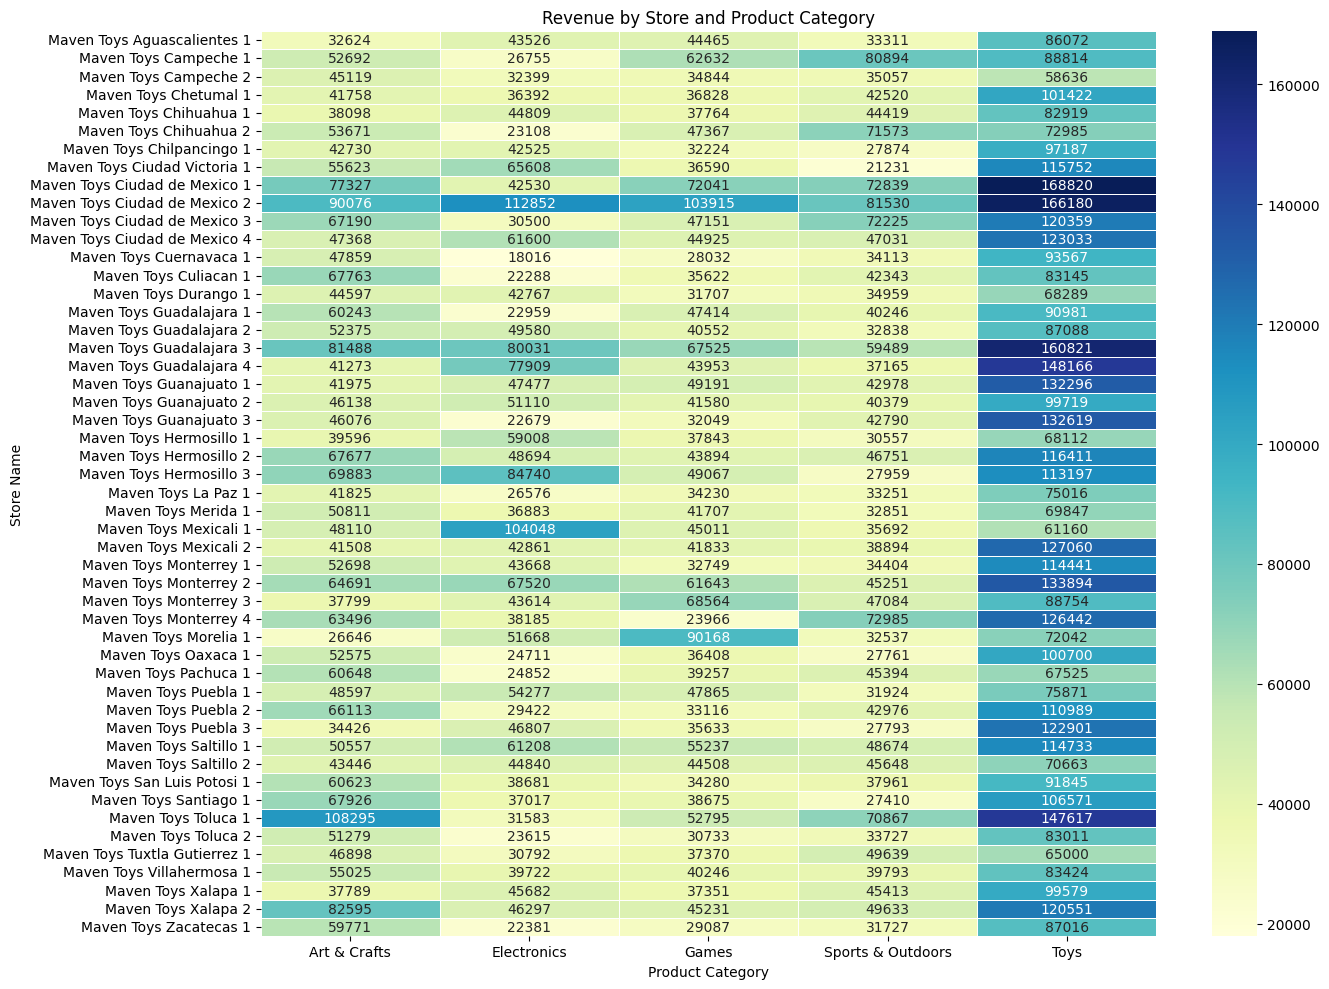

In [202]:
plt.figure(figsize=(14, 10))
sns.heatmap(heat_sales, 
            annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Revenue by Store and Product Category')
plt.xlabel('Product Category')
plt.ylabel('Store Name')
plt.tight_layout()
plt.show()

In [207]:
df1['Year_month'] = df1['Date'].dt.to_period('M')

In [217]:
year_month_sales = df1.groupby('Year_month')['Sales'].sum().reset_index()

In [221]:
year_month_sales['Growth_Rate'] = year_month_sales['Sales'].pct_change()*100

In [227]:
year_month_sales['Growth_Rate'] = year_month_sales['Growth_Rate'].fillna(value=0)

In [232]:
year_month_sales['Growth_Rate'].dtypes

dtype('float64')

Text(0.5, 1.0, 'Growth Rate by Month')

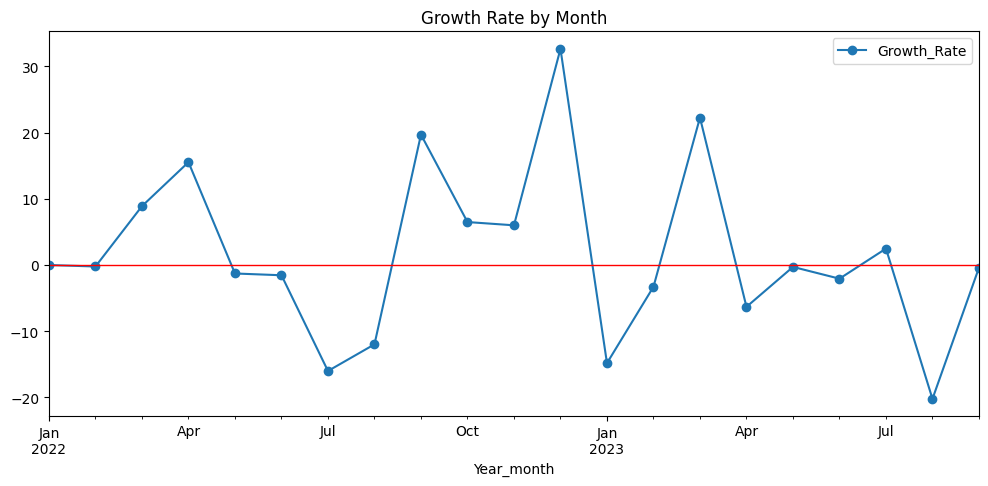

In [250]:
fig ,ax = plt.subplots(figsize = (12 , 5))

year_month_sales.plot(kind='line' , x = 'Year_month' , y = 'Growth_Rate' , marker = 'o' , ax = ax)
ax.axhline(y = 0 ,   color = 'red' , linewidth = 1)
ax.set_title('Growth Rate by Month')

We see 2022 FEBRUARY has the best growth rate.

we can see every Q2 our sale are downed.